# EE446 - TinyML - Assignment 2

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

## Reading Data

In [2]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [3]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [4]:
## INSERT YOUR CODE HERE ##

data = data.drop(columns=['land', 'urgent', 'numfailedlogins', 'numoutboundcmds'])

##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [5]:
## INSERT YOUR CODE HERE ##

data.loc[data['attack'] != 'normal', 'attack'] = 'attack'

In [6]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [7]:
## INSERT YOUR CODE HERE ##

le = LabelEncoder()
encode_cols = ['protocoltype', 'service', 'flag', 'attack']

for col in encode_cols:
    data[col] = le.fit_transform(data[col])

In [8]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [9]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

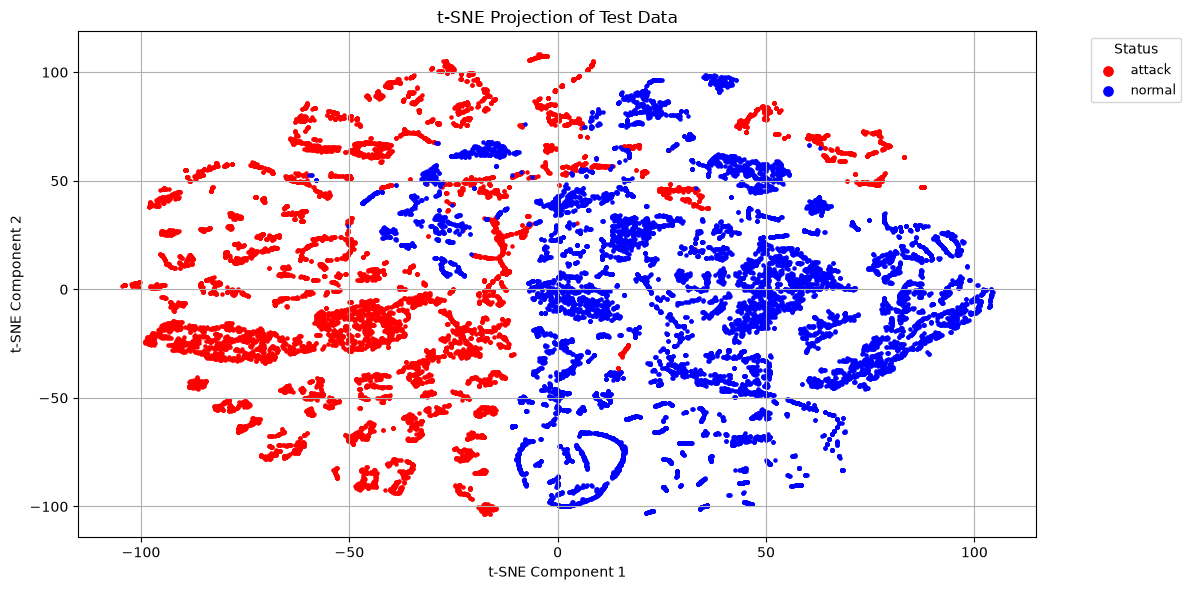

In [10]:
from sklearn.manifold import TSNE
## INSERT YOUR CODE HERE ##

tsne_kwargs = dict(
    n_components=2,
    perplexity=30,
    learning_rate=300,
    random_state=42,
)

X_test_tsne = TSNE(**tsne_kwargs).fit_transform(X_test)

plt.figure(figsize=(12, 6))
plt.scatter(
    X_test_tsne[y_test[:, 0] == 0, 0],
    X_test_tsne[y_test[:, 0] == 0, 1],
    s=5,
    color="red",
    label="attack",
)

plt.scatter(
    X_test_tsne[y_test[:, 0] == 1, 0],
    X_test_tsne[y_test[:, 0] == 1, 1],
    s=5,
    color="blue",
    label="normal",
)

plt.title("t-SNE Projection of Test Data")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(markerscale=3, fontsize=9, title="Status", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

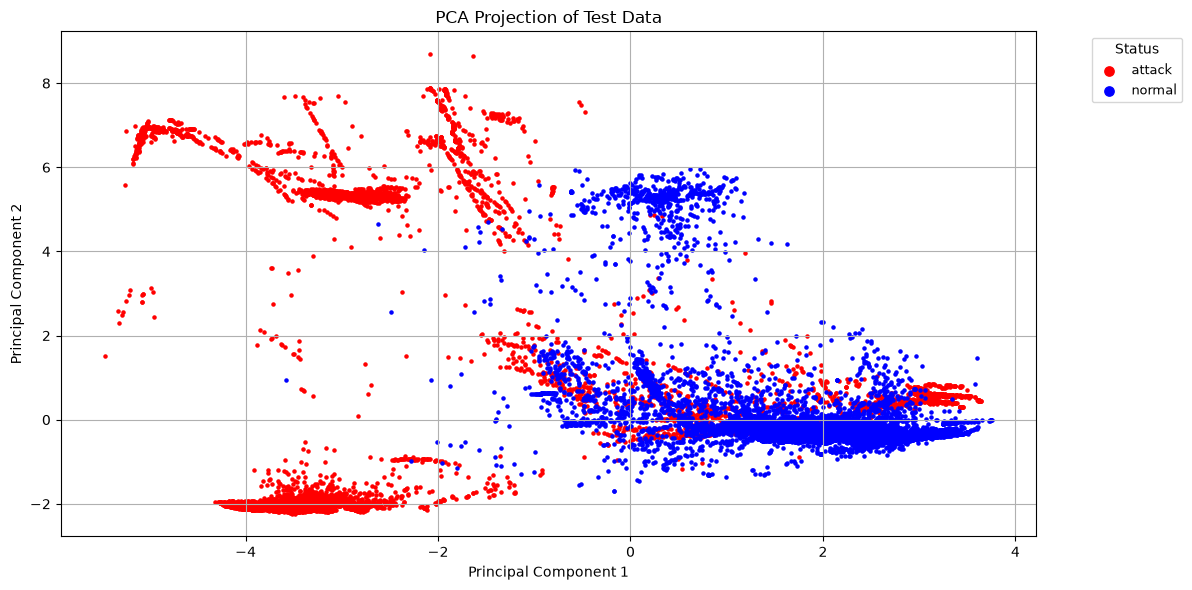

In [11]:
from sklearn.decomposition import PCA
## INSERT YOUR CODE HERE ##

X_test_pca = PCA(n_components=2, random_state=42).fit_transform(X_test)

plt.figure(figsize=(12, 6))
plt.scatter(
    X_test_pca[y_test[:, 0] == 0, 0],
    X_test_pca[y_test[:, 0] == 0, 1],
    s=5,
    color="red",
    label="attack",
)

plt.scatter(
    X_test_pca[y_test[:, 0] == 1, 0],
    X_test_pca[y_test[:, 0] == 1, 1],
    s=5,
    color="blue",
    label="normal",
)

plt.title("PCA Projection of Test Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(markerscale=3, fontsize=9, title="Status", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

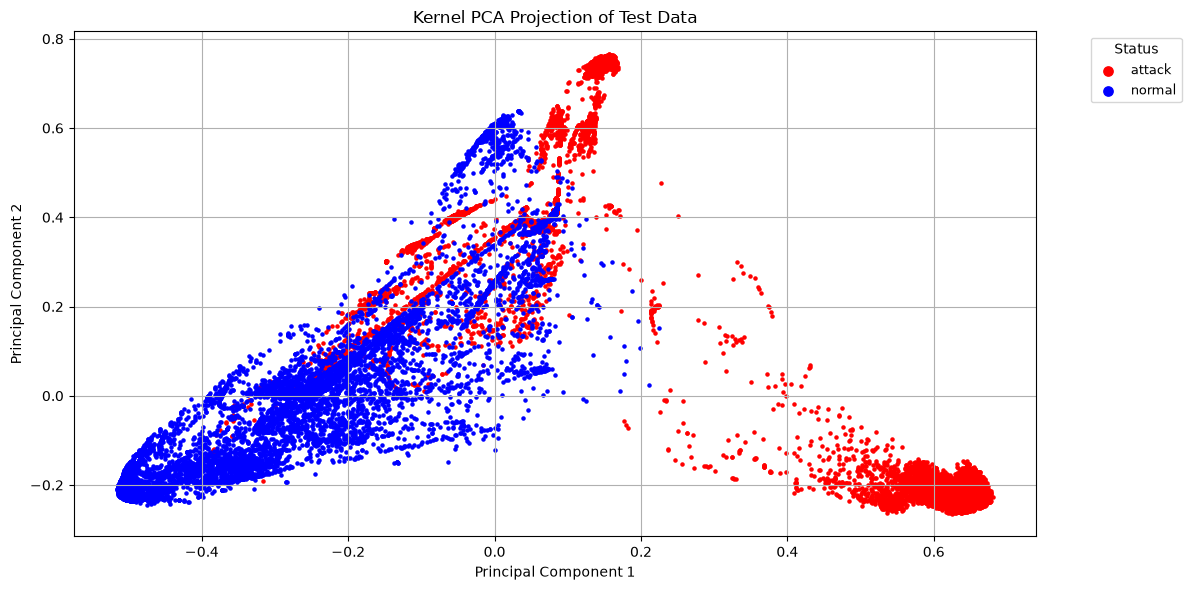

In [12]:
from sklearn.decomposition import KernelPCA
## INSERT YOUR CODE HERE ##

X_test_kernel_pca = KernelPCA(n_components=2, kernel="rbf", random_state=42).fit_transform(X_test)

plt.figure(figsize=(12, 6))
plt.scatter(
    X_test_kernel_pca[y_test[:, 0] == 0, 0],
    X_test_kernel_pca[y_test[:, 0] == 0, 1],
    s=5,
    color="red",
    label="attack",
)

plt.scatter(
    X_test_kernel_pca[y_test[:, 0] == 1, 0],
    X_test_kernel_pca[y_test[:, 0] == 1, 1],
    s=5,
    color="blue",
    label="normal",
)

plt.title("Kernel PCA Projection of Test Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(markerscale=3, fontsize=9, title="Status", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure that the output layer contains one neuron with sigmoid activation.

In [13]:
# Define the DNN model

input_dim = X_train.shape[1]

base_model = Sequential([
    ## INSERT YOUR CODE HERE ##
    Input(shape=(input_dim,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation='sigmoid')
])

base_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                2496      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 4609 (18.00 KB)
Trainable params: 4609 (18.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [14]:
## INSERT YOUR CODE HERE ##

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

base_model.compile(
    optimizer=Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

base_history = base_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
1260/1260 [==============================] - 1s 372us/step - loss: 0.0379 - accuracy: 0.9887 - val_loss: 0.0141 - val_accuracy: 0.9948
Epoch 2/40
1260/1260 [==============================] - 0s 327us/step - loss: 0.0106 - accuracy: 0.9963 - val_loss: 0.0121 - val_accuracy: 0.9952
Epoch 3/40
1260/1260 [==============================] - 0s 321us/step - loss: 0.0086 - accuracy: 0.9969 - val_loss: 0.0107 - val_accuracy: 0.9955
Epoch 4/40
1260/1260 [==============================] - 0s 319us/step - loss: 0.0070 - accuracy: 0.9972 - val_loss: 0.0095 - val_accuracy: 0.9965
Epoch 5/40
1260/1260 [==============================] - 0s 316us/step - loss: 0.0062 - accuracy: 0.9977 - val_loss: 0.0082 - val_accuracy: 0.9969
Epoch 6/40
1260/1260 [==============================] - 0s 314us/step - loss: 0.0057 - accuracy: 0.9979 - val_loss: 0.0079 - val_accuracy: 0.9968
Epoch 7/40
1260/1260 [==============================] - 0s 314us/step - loss: 0.0058 - accuracy: 0.9980 - val_loss: 0.0099 -

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

Test Accuracy: 0.9983

              precision    recall  f1-score   support

  Attack (0)     0.9984    0.9980    0.9982     11711
  Normal (1)     0.9983    0.9986    0.9984     13484

    accuracy                         0.9983     25195
   macro avg     0.9983    0.9983    0.9983     25195
weighted avg     0.9983    0.9983    0.9983     25195



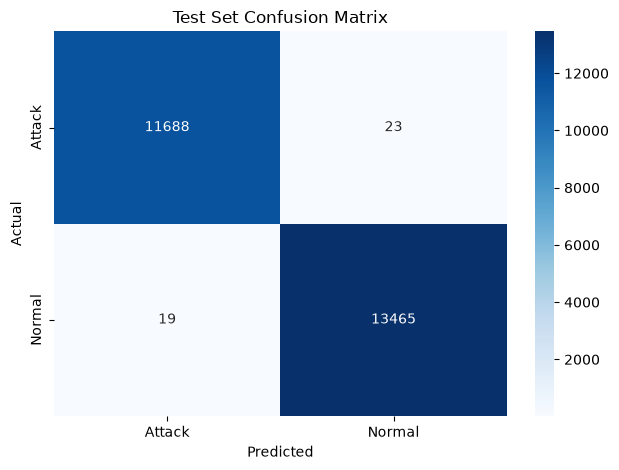

In [15]:
## INSERT YOUR CODE HERE ##

test_probs = base_model.predict(X_test, verbose=0)
test_preds = (test_probs >= 0.5).astype(int) 
test_acc = accuracy_score(y_test[:, 0], test_preds)

print(f"Test Accuracy: {test_acc:.4f}\n")
print(classification_report(y_test[:, 0], test_preds, target_names=["Attack (0)", "Normal (1)"], digits=4))

cm = confusion_matrix(y_test[:, 0], test_preds)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Attack", "Normal"],
    yticklabels=["Attack", "Normal"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

In [16]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement full-integer INT8 post-training quantization on the base_model. Use a representative dataset from X_train to calibrate the activation ranges. Configure the converter to use INT8 operators with INT8 input and output tensors. Designate the resulting quantized model as tflite_quant_model.

In [17]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

## INSERT YOUR CODE HERE ##

def representative_dataset():
    sample_count = min(1000, len(X_train))
    for i in range(sample_count):
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmplz9crqs0/assets


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmplz9crqs0/assets
2026-08-03 22:38:05.630586: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-08-03 22:38:05.630600: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-08-03 22:38:05.630875: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmplz9crqs0
2026-08-03 22:38:05.631167: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-08-03 22:38:05.631170: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmplz9crqs0
2026-08-03 22:38:05.632281: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-08-03 22:38:05.632549: I tensorflow/cc/saved_model/load

In [18]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 84.05 KB
Quantized model size: 7.20 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Quantized Test Accuracy: 0.9983

              precision    recall  f1-score   support

  Attack (0)     0.9976    0.9987    0.9982     11711
  Normal (1)     0.9989    0.9979    0.9984     13484

    accuracy                         0.9983     25195
   macro avg     0.9982    0.9983    0.9983     25195
weighted avg     0.9983    0.9983    0.9983     25195



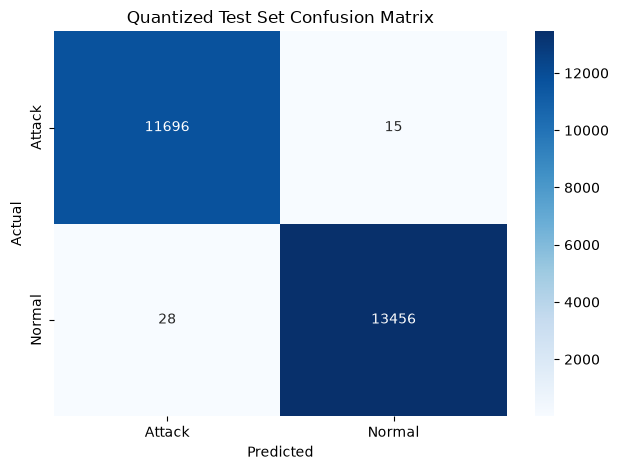

In [19]:
## INSERT YOUR CODE HERE ##

interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

input_scale, input_zero_point = input_details["quantization"]
output_scale, output_zero_point = output_details["quantization"]

quantized_test_probs = []

for i in range(len(X_test)):
    x = X_test[i:i+1].astype(np.float32)

    if input_details["dtype"] == np.int8:
        x = np.round(x / input_scale + input_zero_point).astype(np.int8)
    elif input_details["dtype"] == np.uint8:
        x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
    else:
        x = x.astype(input_details["dtype"])


    interpreter.set_tensor(input_details["index"], x)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details["index"])

    if output_details["dtype"] in (np.int8, np.uint8):
        output = (output.astype(np.float32) - output_zero_point) * output_scale

    quantized_test_probs.append(output.item())

quantized_test_probs = np.array(quantized_test_probs)
quantized_test_preds = (quantized_test_probs >= 0.5).astype(int)

quant_test_acc = accuracy_score(y_test[:, 0], quantized_test_preds)

print(f"Quantized Test Accuracy: {quant_test_acc:.4f}\n")
print(classification_report(y_test[:, 0], quantized_test_preds, target_names=["Attack (0)", "Normal (1)"], digits=4))

cm = confusion_matrix(y_test[:, 0], quantized_test_preds)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Attack", "Normal"],
    yticklabels=["Attack", "Normal"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Quantized Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

## Converting tflite_quant_model to C and creating the header file

In [20]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [21]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [22]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11024922321249885, -0.12470615670462065, 2.127289198557699, 
    -1.8517440856201013, -0.00776224074056876, -0.004918644383724874, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059747, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.07953629996013183, -0.32680812408381416, -0.6372092679572258, 
    -0.6319290328885425, 2.7464027950834815, 2.715364578035608, 
    -1.3896685914060654, 0.09398821334722901, -0.37455970440553465, 
    0.7343425609306344, -1.0085879300414886, -1.1164815559390462, 
    -0.015620856278641512, -0.4801968475158174, -0.28910340026287856, 
    -0.6395319051152512, -0.6248707997445304, 2.8744095478204597, 
    2.753913722653446, -0.6563667617603728, -0.1102492232124

In [23]:
ytest=y_test[0:5]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 5;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[5][1] = {
    0, 0, 0, 0, 1
};



In [24]:
random_picks = (
    np.random.choice(len(X_test) - 5, size=10, replace=False) + 5
)

In [25]:
print(c_writer.create_array(X_test[random_picks,:],"float","X_test_10"))

const unsigned int X_test_10_dim1 = 10;
const unsigned int X_test_10_dim2 = 38;

const float X_test_10[10][38] = {
    -0.11024922321249885, -0.12470615670462065, 1.0873051789289023, 
    -1.1080711219467763, -0.00776224074056876, -0.004918644383724874, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059747, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.7257784945454897, -0.3681102129968653, -0.6372092679572258, 
    -0.6319290328885425, 2.7464027950834815, 2.715364578035608, 
    0.7712831058493207, -0.349683030873482, -0.37455970440553465, 
    0.7343425609306344, -1.0356876376568842, -1.161030186584037, 
    1.9958013748272787, 2.432463121620216, -0.28910340026287856, 
    -0.6395319051152512, -0.6248707997445304, 2.548205130687663, 
    2.753913722653446, -0.6563667617603728, -0.110249223212

In [26]:
print(c_writer.create_array(y_test[random_picks],"uint8_t","y_test_10"))

const unsigned int y_test_10_dim1 = 10;
const unsigned int y_test_10_dim2 = 1;

const uint8_t y_test_10[10][1] = {
    0, 1, 1, 0, 1, 1, 1, 0, 1, 0
};

